In [1]:
# вычисление численного решения
# уравнения КдВ в соответствие с
# разностной схемой (9.131)
# с периодическими граничными условиями (9.132)

# Ячейка № 1

# подключение библиотеки numpy
import numpy as np

# подключение пакета matplotlib.pyplot
import matplotlib.pyplot as plt

In [2]:
# Ячейка № 2

# задание функции, отключающей отображение
# значений координатной стеки
def Off_Labes_Tick(ax):
    for tick in ax.xaxis.get_major_ticks():
        tick.tick1line.set_visible(False)
        tick.tick2line.set_visible(False)
        tick.label1.set_visible(False)
        tick.label2.set_visible(False)
    for tick in ax.yaxis.get_major_ticks():
        tick.tick1line.set_visible(False)
        tick.tick2line.set_visible(False)
        tick.label1.set_visible(False)
        tick.label2.set_visible(False)

    return

In [ ]:
# Ячейка № 3

# задание значений параметров
# начального возмущения
Xm = 0.5
A = 0.5
S = 0.08

# вычисление координат узлов
# координатной сетки
Nx = 201
x = np.linspace(0, 1, Nx)

# вычисление шага координатной сетки
dx = x[1] - x[0]

# задание числа шагов по времени
Nt = 10**5

# инициализация массива размерностью Nt x Nx,
# используемого для хранения текущего
# решения уравнения КдВ
v = np.zeros([Nt, Nx])

# вычисление значений начального условия
v[0, :] = A * np.exp(-(((x[:] - Xm) / S) ** 2) / 2)

# задание параметров разностной схемы (9.131)
c = 5 * 10**-5
dt = 4 * 10**-4

# вычисление коэффициентов, входящих в (9.131)
Coeff1 = dt / (2 * dx)
Coeff2 = c * dt / (2 * dx**3)

# инициализация служебного массива,
# используемого для вычисления численного решения
# уравнения КдВ в соответствие с (9.131)
V = np.zeros(Nx)

# вычисление решений уравнения КдВ
# в соответствие с (9.131)
for i in range(Nt - 1):
    V[:] = v[i, :]
    for j in range(Nx):
        # вычисление численных решений
        # с учетом периодических граничных условий (9.132)
        if j == 0:
            V[0] = -Coeff1 * V[0] * (V[1] - V[Nx - 1]) - Coeff2 * (
                V[2] - 2 * V[1] + 2 * V[Nx - 1] - V[Nx - 2]
            )
        if j == 1:
            V[1] = -Coeff1 * V[1] * (V[2] - V[0]) - Coeff2 * (
                V[3] - 2 * V[2] + 2 * V[0] - V[Nx - 1]
            )
        if j == Nx - 2:
            V[Nx - 2] = -Coeff1 * V[Nx - 2] * (V[Nx - 1] - V[Nx - 3]) - Coeff2 * (
                V[0] - 2 * V[Nx - 1] + 2 * V[Nx - 3] - V[Nx - 4]
            )
        if j == Nx - 1:
            V[Nx - 1] = -Coeff1 * V[Nx - 1] * (V[0] - V[Nx - 2]) - Coeff2 * (
                V[1] - 2 * V[0] + 2 * V[Nx - 2] - V[Nx - 3]
            )
        # вычисление численного решения уравнения КДВ
        # в соответствие с (9.132)
        if (j > 1) & (j < Nx - 2):
            V[j] = -Coeff1 * V[j] * (V[j + 1] - V[j - 1]) - Coeff2 * (
                V[j + 2] - 2 * V[j + 1] + 2 * V[j - 1] - V[j - 2]
            )
        V[j] = v[i, j] + V[j]
    # перемещение найденного численного решения
    # из массива V
    # в i+1-ую строку матрицы v
    v[i + 1, :] = V[:]


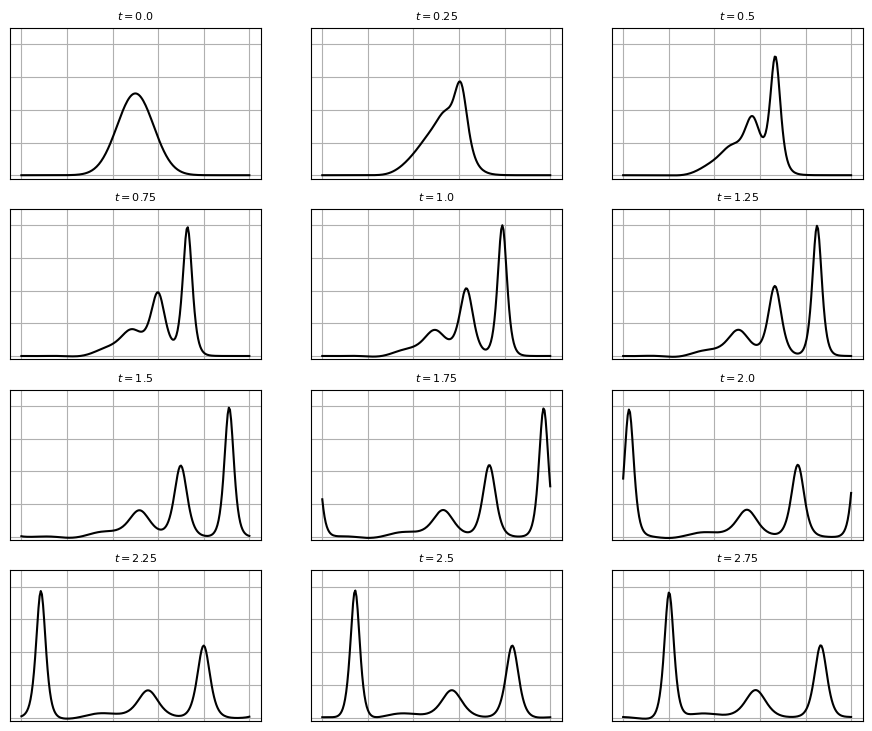

In [4]:
# Ячейка № 4

# визуализация численных решений уравнения КдВ
# в выбранные моменты времени (начало)

# визуализация численного решения уравнения КдВ
# в моменты времени 0, 0.25, ..., 2.75
Nx = 4
Ny = 3
Dt = 0.25

fig = plt.figure(figsize=(11, 9))

for i in range(12):
    Time = i * Dt
    ax = fig.add_subplot(Nx, Ny, i + 1)
    ax.plot(x[:], v[int(Time / dt), :], "black")
    ax.grid(True)
    Off_Labes_Tick(ax)
    plt.title(r"$t =$" + str(Time), fontsize=8)
    plt.ylim([-0.021, 0.9])

plt.show()

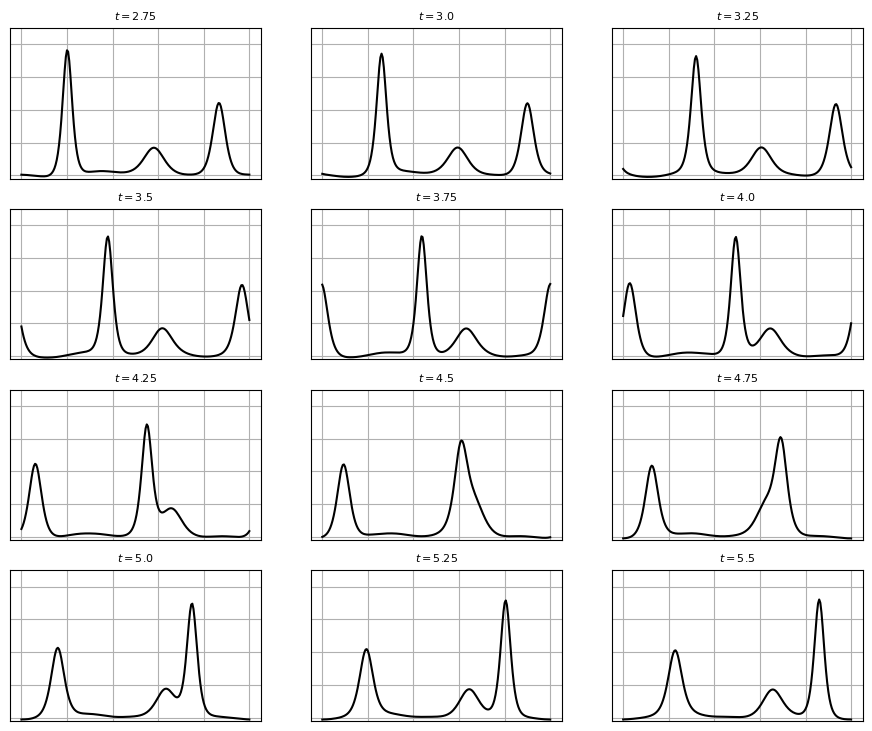

In [5]:
# ячейка № 3
# визуализация численных решений уравнения КдВ
# в выбранные моменты времени (окончание)

Nx = 4
Ny = 3
fig = plt.figure(figsize=(11, 9))

# визуализация численного решения уравнения КдВ
# в моменты времени 3.0, 3.25, ..., 5.75

Time_Start = Time - Dt
for i in range(12):
    Time = (i + 1) * Dt
    ax = fig.add_subplot(Nx, Ny, i + 1)
    ax.plot(x[:], v[int((Time_Start + Time) / dt), :], "black")
    ax.grid(True)
    Off_Labes_Tick(ax)
    plt.title(r"$t =$" + str(Time_Start + Time), fontsize=8)
    plt.ylim([-0.021, 0.9])

plt.show()